# 01 - Extended and Unscented Kalman Filters

## Objective

This notebook compares the **Extended Kalman Filter (EKF)** and the
**Unscented Kalman Filter (UKF)** on two canonical nonlinear problems:

1. A damped **nonlinear pendulum** with `sin(theta)` observations.
2. A 2-D **target tracking** scenario with range/bearing measurements.

Both filters extend the linear Kalman recursion to nonlinear
state-space models

$$
\begin{aligned}
x_{k} &= f(x_{k-1}) + w_{k-1}, \quad w_{k-1} \sim \mathcal{N}(0, Q) \\
y_{k} &= h(x_{k}) + v_{k},   \quad v_{k} \sim \mathcal{N}(0, H)
\end{aligned}
$$

but use very different strategies.

## EKF — local linearisation

Replace the nonlinear predict/update by their first-order Taylor
expansions around the current estimate via Jacobians
$F_k = \partial f/\partial x\big|_{\hat x_{k-1|k-1}}$ and
$H_k = \partial h/\partial x\big|_{\hat x_{k|k-1}}$:

$$
\begin{aligned}
\hat x_{k|k-1} &= f(\hat x_{k-1|k-1}) \\
P_{k|k-1}     &= F_k P_{k-1|k-1} F_k^\top + Q \\
K_k &= P_{k|k-1} H_k^\top (H_k P_{k|k-1} H_k^\top + R)^{-1} \\
\hat x_{k|k} &= \hat x_{k|k-1} + K_k (y_k - h(\hat x_{k|k-1})) \\
P_{k|k}      &= (I - K_k H_k) P_{k|k-1}
\end{aligned}
$$

Cheap (one pass through $f$ and $h$), exact for linear models,
but loses second-order moment information and can diverge when
curvature is strong.

## UKF — unscented transform

Pick $2n{+}1$ deterministic **sigma points** with weights that match the
mean and covariance of $\mathcal N(\hat x, P)$:

$$
\mathcal X^{(0)} = \hat x, \qquad
\mathcal X^{(i)} = \hat x \pm \bigl(\sqrt{(n+\lambda) P}\bigr)_{i},
$$

propagate every one through $f$ (or $h$), and **reassemble the
moments**:

$$
\hat x_{k|k-1} = \sum_i W^{(i)}_m f(\mathcal X^{(i)}_{k-1}), \qquad
P_{k|k-1} = \sum_i W^{(i)}_c \big(\cdot\big)\big(\cdot\big)^\top + Q.
$$

No Jacobians needed; captures second-order moment effects exactly
for any smooth $f, h$. The price is $2n{+}1$ function evaluations
per step.

## Takeaways

* For mild nonlinearities (pendulum) EKF and UKF perform similarly.
* For strong nonlinearities (range/bearing tracking) the UKF is
  usually more robust — the Jacobian of $\mathrm{atan2}$ blows up
  near the origin, while the UKF evaluates $h$ at sigma points and
  recovers sensible second moments.


In [1]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kalmanbox.filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
)

DATA = Path('data')
plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})
np.set_printoptions(precision=4, suppress=True)

pend = pd.read_csv(DATA / 'pendulum.csv')
targ = pd.read_csv(DATA / 'target_tracking.csv')
print('pendulum:', pend.shape, 'columns:', pend.columns.tolist())
print('target_tracking:', targ.shape, 'columns:', targ.columns.tolist())
pend.head()


pendulum: (200, 4) columns: ['t', 'x_theta', 'x_theta_dot', 'y_sin_theta']
target_tracking: (100, 7) columns: ['t', 'x_x', 'x_vx', 'x_y', 'x_vy', 'y_range', 'y_bearing']


,t,x_theta,x_theta_dot,y_sin_theta
0,0.0,1.200000,0.000000,1.033311
1,0.1,1.108597,-0.914026,1.317319
2,0.2,0.929284,-1.793133,0.828367
3,0.3,0.671449,-2.578352,0.815303
4,0.4,0.352678,-3.187712,-0.269640


## Example 1 — Pendulum with EKF

The damped pendulum has continuous dynamics

$$
\ddot\theta + \frac{g}{L}\sin\theta = w(t),
$$

discretised in the data generator via a symplectic (semi-implicit) Euler step

$$
\dot\theta_{k+1} = \dot\theta_k - \frac{g}{L}\sin(\theta_k)\,\Delta t + \Delta t\,w_k,
\qquad \theta_{k+1} = \theta_k + \Delta t\,\dot\theta_{k+1}.
$$

Let $x = [\theta, \dot\theta]^\top$. Then

$$
f(x) = \begin{bmatrix}
\theta + \Delta t\,\dot\theta - \Delta t^2 \frac{g}{L}\sin\theta \\
\dot\theta - \Delta t\,\frac{g}{L}\sin\theta
\end{bmatrix},
\qquad
F_k = \frac{\partial f}{\partial x}\bigg|_{\hat x_{k-1|k-1}}
= \begin{bmatrix}
1 - \Delta t^2 \frac{g}{L}\cos\theta & \Delta t \\[2pt]
-\Delta t\,\frac{g}{L}\cos\theta     & 1
\end{bmatrix}.
$$

The observation equation $y_k = \sin\theta_k + v_k$ gives

$$
h(x) = \sin\theta, \qquad H_k = [\cos\theta \;\; 0].
$$

These are the only four quantities that the EKF needs to run on this problem.


In [2]:
# Pendulum EKF model
DT = 0.1
G = 9.81
L_ROD = 1.0
SIGMA_PROC_PEND = 0.01
SIGMA_OBS_PEND = 0.3
OMEGA2 = G / L_ROD


class PendulumEKFModel:
    '''EKF model for the nonlinear pendulum.

    The transition corresponds to the symplectic Euler step used in the
    data generator; the observation is y = sin(theta).
    '''

    def __init__(self, dt: float = DT) -> None:
        self.dt = dt
        self.k_states = 2
        self.k_endog = 1
        # Selection matrix: noise enters theta_dot (scaled by dt) and theta (scaled by dt**2).
        self.R = np.array([[dt], [1.0]])
        self.Q = np.array([[(dt * SIGMA_PROC_PEND) ** 2]])
        self.H = np.array([[SIGMA_OBS_PEND ** 2]])
        self.a1 = np.array([1.2, 0.0])
        self.P1 = np.diag([0.5, 0.5])

    def transition(self, x, t):
        theta, theta_dot = x
        theta_dot_new = theta_dot - self.dt * OMEGA2 * np.sin(theta)
        theta_new = theta + self.dt * theta_dot_new
        return np.array([theta_new, theta_dot_new])

    def transition_jacobian(self, x, t):
        theta, _ = x
        dt2 = self.dt ** 2
        return np.array([
            [1.0 - dt2 * OMEGA2 * np.cos(theta), self.dt],
            [-self.dt * OMEGA2 * np.cos(theta), 1.0],
        ])

    def observation(self, x, t):
        return np.array([np.sin(x[0])])

    def observation_jacobian(self, x, t):
        return np.array([[np.cos(x[0]), 0.0]])


y_pend = pend[['y_sin_theta']].to_numpy()
x_true_pend = pend[['x_theta', 'x_theta_dot']].to_numpy()
t_pend = pend['t'].to_numpy()

ekf = ExtendedKalmanFilter()
model_pend_ekf = PendulumEKFModel()

tic = time.perf_counter()
out_ekf = ekf.filter(y_pend, model_pend_ekf)
toc = time.perf_counter()
time_ekf_pend = toc - tic

theta_hat_ekf = out_ekf.filtered_state[:, 0]
rmse_theta_ekf = float(np.sqrt(np.mean((theta_hat_ekf - x_true_pend[:, 0]) ** 2)))
print(f'EKF pendulum: RMSE(theta) = {rmse_theta_ekf:.4f}   time = {time_ekf_pend * 1e3:.1f} ms')
print(f'Log-likelihood = {out_ekf.loglike:.2f}')


EKF pendulum: RMSE(theta) = 0.3793   time = 32.4 ms
Log-likelihood = -144.49


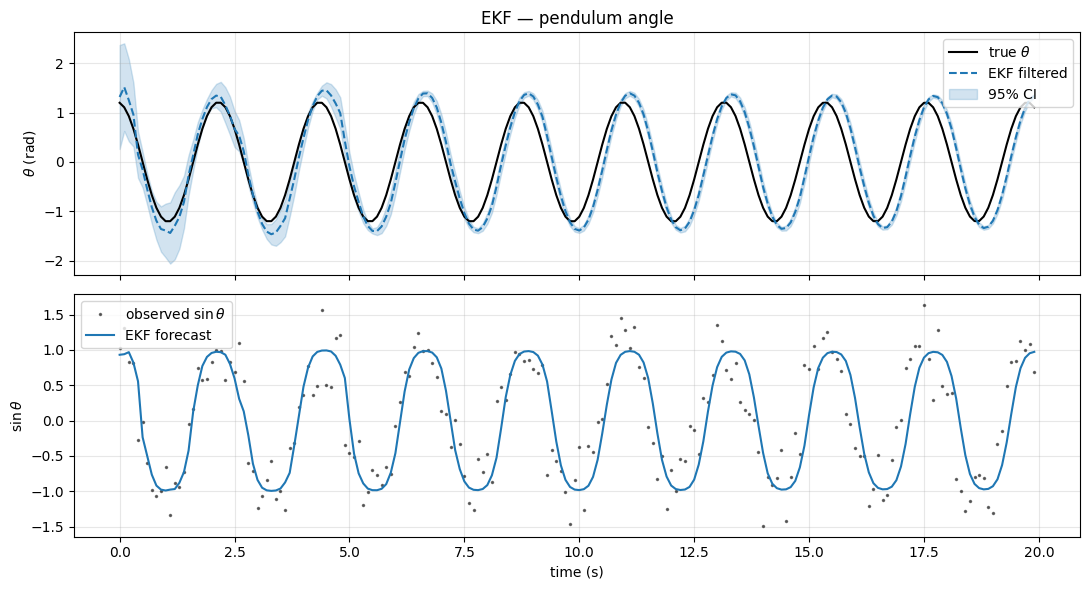

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(t_pend, x_true_pend[:, 0], 'k-', label=r'true $\theta$')
axes[0].plot(t_pend, theta_hat_ekf, 'C0--', label='EKF filtered')
ci = 1.96 * np.sqrt(out_ekf.filtered_cov[:, 0, 0])
axes[0].fill_between(t_pend, theta_hat_ekf - ci, theta_hat_ekf + ci,
                     alpha=0.2, color='C0', label='95% CI')
axes[0].set_ylabel(r'$\theta$ (rad)')
axes[0].legend(loc='best')
axes[0].set_title('EKF — pendulum angle')

axes[1].plot(t_pend, y_pend[:, 0], 'k.', ms=3, alpha=0.5, label='observed $\\sin\\theta$')
axes[1].plot(t_pend, out_ekf.forecast[:, 0], 'C0-', label='EKF forecast')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel(r'$\sin\theta$')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


## Example 1b — Pendulum with UKF

Now the exact same dynamics are filtered with the UKF. Notice that the
class has **no Jacobians**: only $f(\cdot)$ and $h(\cdot)$. The price of
that simplicity is $2n+1 = 5$ evaluations of $f$ and $h$ per time step
(against one for EKF), but unlike EKF the moments propagated through $f$
and $h$ are second-order-accurate.


In [4]:
class PendulumUKFModel:
    '''UKF model for the pendulum: transition and observation only.'''

    def __init__(self, dt: float = DT) -> None:
        self.dt = dt
        self.k_states = 2
        self.k_endog = 1
        self.R = np.array([[dt], [1.0]])
        self.Q = np.array([[(dt * SIGMA_PROC_PEND) ** 2]])
        self.H = np.array([[SIGMA_OBS_PEND ** 2]])
        self.a1 = np.array([1.2, 0.0])
        self.P1 = np.diag([0.5, 0.5])

    def transition(self, x, t):
        theta, theta_dot = x
        theta_dot_new = theta_dot - self.dt * OMEGA2 * np.sin(theta)
        return np.array([theta + self.dt * theta_dot_new, theta_dot_new])

    def observation(self, x, t):
        return np.array([np.sin(x[0])])


ukf = UnscentedKalmanFilter(alpha=1e-1, beta=2.0, kappa=0.0)
model_pend_ukf = PendulumUKFModel()

tic = time.perf_counter()
out_ukf = ukf.filter(y_pend, model_pend_ukf)
toc = time.perf_counter()
time_ukf_pend = toc - tic

theta_hat_ukf = out_ukf.filtered_state[:, 0]
rmse_theta_ukf = float(np.sqrt(np.mean((theta_hat_ukf - x_true_pend[:, 0]) ** 2)))
print(f'UKF pendulum: RMSE(theta) = {rmse_theta_ukf:.4f}   time = {time_ukf_pend * 1e3:.1f} ms')
print(f'Log-likelihood = {out_ukf.loglike:.2f}')


UKF pendulum: RMSE(theta) = 0.2022   time = 74.0 ms
Log-likelihood = -65.40


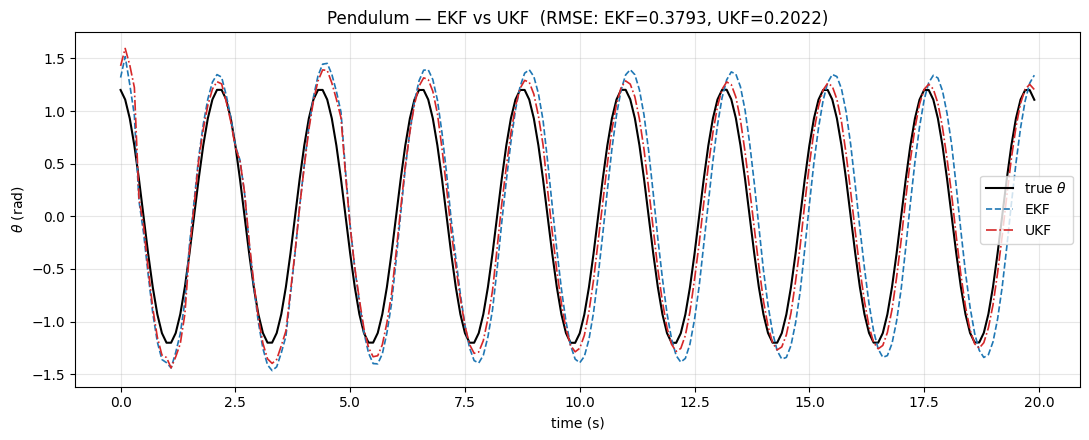

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_pend, x_true_pend[:, 0], 'k-', label=r'true $\theta$', lw=1.5)
ax.plot(t_pend, theta_hat_ekf, 'C0--', label='EKF', lw=1.2)
ax.plot(t_pend, theta_hat_ukf, 'C3-.', label='UKF', lw=1.2)
ax.set_xlabel('time (s)')
ax.set_ylabel(r'$\theta$ (rad)')
ax.set_title(
    f'Pendulum — EKF vs UKF  '
    f'(RMSE: EKF={rmse_theta_ekf:.4f}, UKF={rmse_theta_ukf:.4f})'
)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## Example 2 — Target tracking with EKF

The target state is $[x, v_x, y, v_y]^\top$ with a **linear** near-constant-velocity
transition

$$
F = \begin{bmatrix}
1 & \Delta t & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & \Delta t \\
0 & 0 & 0 & 1
\end{bmatrix}.
$$

The **nonlinearity** lives in the observation equation — a sensor at
the origin measures range and bearing

$$
h(x) = \begin{bmatrix} r \\ \phi \end{bmatrix} = \begin{bmatrix} \sqrt{x^2 + y^2} \\ \mathrm{atan2}(y, x) \end{bmatrix},
$$

with Jacobian

$$
H_k = \begin{bmatrix}
\frac{x}{r} & 0 & \frac{y}{r} & 0 \\
-\frac{y}{r^2} & 0 & \frac{x}{r^2} & 0
\end{bmatrix},
$$

which is ill-behaved near the origin. This is the canonical textbook example
where the EKF's linearisation can mislead the filter.


In [6]:
DT_T = 1.0
SIGMA_RANGE = 5.0
SIGMA_BEARING = 0.05
SIGMA_PROC_T = 0.1

F_TARG = np.array([
    [1.0, DT_T, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, DT_T],
    [0.0, 0.0, 0.0, 1.0],
])
# Van Loan form for piecewise constant white-noise acceleration.
q_c = SIGMA_PROC_T ** 2
Q_TARG = q_c * np.array([
    [DT_T ** 3 / 3, DT_T ** 2 / 2, 0, 0],
    [DT_T ** 2 / 2, DT_T, 0, 0],
    [0, 0, DT_T ** 3 / 3, DT_T ** 2 / 2],
    [0, 0, DT_T ** 2 / 2, DT_T],
])


class TargetEKFModel:
    '''EKF with linear transition and nonlinear range/bearing observations.'''

    def __init__(self, a1, P1) -> None:
        self.k_states = 4
        self.k_endog = 2
        self.R = np.eye(4)
        self.Q = Q_TARG
        self.H = np.diag([SIGMA_RANGE ** 2, SIGMA_BEARING ** 2])
        self.a1 = a1
        self.P1 = P1

    def transition(self, x, t):
        return F_TARG @ x

    def transition_jacobian(self, x, t):
        return F_TARG

    def observation(self, x, t):
        xp, _, yp, _ = x
        r = np.hypot(xp, yp)
        phi = np.arctan2(yp, xp)
        return np.array([r, phi])

    def observation_jacobian(self, x, t):
        xp, _, yp, _ = x
        r2 = xp * xp + yp * yp
        r = np.sqrt(max(r2, 1e-12))
        return np.array([
            [xp / r, 0.0, yp / r, 0.0],
            [-yp / r2, 0.0, xp / r2, 0.0],
        ])


class TargetUKFModel:
    '''Same dynamics as TargetEKFModel, but no Jacobians required.'''

    def __init__(self, a1, P1) -> None:
        self.k_states = 4
        self.k_endog = 2
        self.R = np.eye(4)
        self.Q = Q_TARG
        self.H = np.diag([SIGMA_RANGE ** 2, SIGMA_BEARING ** 2])
        self.a1 = a1
        self.P1 = P1

    def transition(self, x, t):
        return F_TARG @ x

    def observation(self, x, t):
        xp, _, yp, _ = x
        r = np.hypot(xp, yp)
        phi = np.arctan2(yp, xp)
        return np.array([r, phi])


y_targ = targ[['y_range', 'y_bearing']].to_numpy()
x_true_targ = targ[['x_x', 'x_vx', 'x_y', 'x_vy']].to_numpy()
t_targ = targ['t'].to_numpy()

# Initialise from the first range/bearing measurement
r0, phi0 = y_targ[0]
a1_targ = np.array([r0 * np.cos(phi0), 0.0, r0 * np.sin(phi0), 0.0])
P1_targ = np.diag([SIGMA_RANGE ** 2, 10.0, SIGMA_RANGE ** 2, 10.0])

model_targ_ekf = TargetEKFModel(a1_targ, P1_targ)
model_targ_ukf = TargetUKFModel(a1_targ, P1_targ)

tic = time.perf_counter()
out_ekf_t = ekf.filter(y_targ, model_targ_ekf)
time_ekf_targ = time.perf_counter() - tic

tic = time.perf_counter()
out_ukf_t = ukf.filter(y_targ, model_targ_ukf)
time_ukf_targ = time.perf_counter() - tic

xy_true = x_true_targ[:, [0, 2]]
xy_ekf = out_ekf_t.filtered_state[:, [0, 2]]
xy_ukf = out_ukf_t.filtered_state[:, [0, 2]]

rmse_ekf_pos = float(np.sqrt(np.mean(np.sum((xy_ekf - xy_true) ** 2, axis=1))))
rmse_ukf_pos = float(np.sqrt(np.mean(np.sum((xy_ukf - xy_true) ** 2, axis=1))))
print(f'EKF target: position RMSE = {rmse_ekf_pos:.3f}   time = {time_ekf_targ * 1e3:.1f} ms')
print(f'UKF target: position RMSE = {rmse_ukf_pos:.3f}   time = {time_ukf_targ * 1e3:.1f} ms')


EKF target: position RMSE = 3.608   time = 17.5 ms
UKF target: position RMSE = 3.610   time = 49.8 ms


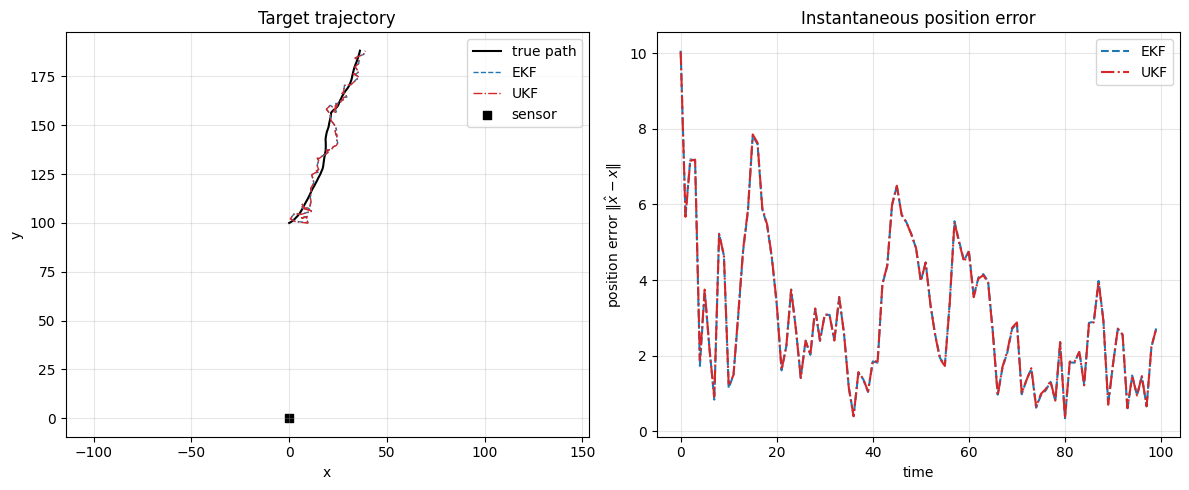

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xy_true[:, 0], xy_true[:, 1], 'k-', label='true path', lw=1.5)
axes[0].plot(xy_ekf[:, 0], xy_ekf[:, 1], 'C0--', label='EKF', lw=1.0)
axes[0].plot(xy_ukf[:, 0], xy_ukf[:, 1], 'C3-.', label='UKF', lw=1.0)
axes[0].scatter([0], [0], marker='s', color='k', label='sensor')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Target trajectory')
axes[0].legend(loc='best')
axes[0].set_aspect('equal', adjustable='datalim')

err_ekf = np.sqrt(np.sum((xy_ekf - xy_true) ** 2, axis=1))
err_ukf = np.sqrt(np.sum((xy_ukf - xy_true) ** 2, axis=1))
axes[1].plot(t_targ, err_ekf, 'C0--', label='EKF')
axes[1].plot(t_targ, err_ukf, 'C3-.', label='UKF')
axes[1].set_xlabel('time')
axes[1].set_ylabel(r'position error $\| \hat x - x\|$')
axes[1].set_title('Instantaneous position error')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


## Stress test — when EKF falls over and UKF survives

The default range/bearing tracking is benign enough that the two
filters agree to four decimal places — the target stays ~50 units
from the sensor, where both $h(x)$ and its Jacobian are well behaved.

A much harsher stress is imposed by swapping the linear range for a
**received-signal-strength (RSS)** measurement of the form

$$
y^{(1)}_k = \frac{1}{r_k^{2}} + \mathrm{noise},
$$

which corresponds to the $1/r^2$ intensity fall-off of an omnidirectional
acoustic or RF source. This is strongly nonlinear: a 10% error in
position near $r = 20$ maps to a ~20% error in the observation.
Its Jacobian

$$
\frac{\partial}{\partial x}\,r^{-2} = -\frac{2x}{r^{4}},
$$

is highly state-dependent, which is exactly where first-order
linearisation (EKF) is least reliable, and where the second-order
UKF approximation wins.


In [8]:
# Simulate a constant-velocity target observed in (1/r^2, bearing).
SIGMA_RSS = 1e-4
SIGMA_BEARING_RSS = 0.05
SIGMA_PROC_RSS = 0.05


def simulate_rss(
    n: int = 100,
    dt: float = 1.0,
    x0: tuple[float, float, float, float] = (20.0, -0.3, 15.0, -0.1),
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    Q = SIGMA_PROC_RSS ** 2 * np.array([
        [dt ** 3 / 3, dt ** 2 / 2, 0, 0],
        [dt ** 2 / 2, dt, 0, 0],
        [0, 0, dt ** 3 / 3, dt ** 2 / 2],
        [0, 0, dt ** 2 / 2, dt],
    ])
    L = np.linalg.cholesky(Q + 1e-12 * np.eye(4))
    x = np.empty((n, 4))
    x[0] = x0
    for k in range(n - 1):
        x[k + 1] = F_TARG @ x[k] + L @ rng.standard_normal(4)
    r = np.hypot(x[:, 0], x[:, 2])
    phi = np.arctan2(x[:, 2], x[:, 0])
    y = np.column_stack([
        1.0 / r ** 2 + rng.normal(0.0, SIGMA_RSS, n),
        phi + rng.normal(0.0, SIGMA_BEARING_RSS, n),
    ])
    return x, y


class RSSBearingEKFModel:
    '''EKF model for RSS + bearing observations.'''

    def __init__(self, a1, P1) -> None:
        self.k_states = 4
        self.k_endog = 2
        self.R = np.eye(4)
        self.Q = SIGMA_PROC_RSS ** 2 * np.array([
            [DT_T ** 3 / 3, DT_T ** 2 / 2, 0, 0],
            [DT_T ** 2 / 2, DT_T, 0, 0],
            [0, 0, DT_T ** 3 / 3, DT_T ** 2 / 2],
            [0, 0, DT_T ** 2 / 2, DT_T],
        ])
        self.H = np.diag([SIGMA_RSS ** 2, SIGMA_BEARING_RSS ** 2])
        self.a1 = a1
        self.P1 = P1

    def transition(self, x, t):
        return F_TARG @ x

    def transition_jacobian(self, x, t):
        return F_TARG

    def observation(self, x, t):
        xp, _, yp, _ = x
        r = max(np.hypot(xp, yp), 1e-6)
        return np.array([1.0 / r ** 2, np.arctan2(yp, xp)])

    def observation_jacobian(self, x, t):
        xp, _, yp, _ = x
        r2 = xp * xp + yp * yp
        r = max(np.sqrt(r2), 1e-6)
        return np.array([
            [-2.0 * xp / r ** 4, 0.0, -2.0 * yp / r ** 4, 0.0],
            [-yp / r2,           0.0, xp / r2,            0.0],
        ])


class RSSBearingUKFModel(RSSBearingEKFModel):
    '''UKF just reuses transition/observation; the Jacobians are ignored.'''


x_true_rss, y_rss = simulate_rss()
t_rss = np.arange(y_rss.shape[0], dtype=float)
xy_true_rss = x_true_rss[:, [0, 2]]

# Initialise with crude prior: right bearing, nominal range = 40.
phi0_rss = y_rss[0, 1]
r0_guess = 40.0
a1_rss = np.array([r0_guess * np.cos(phi0_rss), 0.0,
                   r0_guess * np.sin(phi0_rss), 0.0])
P1_rss = np.diag([100.0, 4.0, 100.0, 4.0])

out_ekf_rss = ekf.filter(y_rss, RSSBearingEKFModel(a1_rss, P1_rss))
out_ukf_rss = ukf.filter(y_rss, RSSBearingUKFModel(a1_rss, P1_rss))

xy_ekf_rss = out_ekf_rss.filtered_state[:, [0, 2]]
xy_ukf_rss = out_ukf_rss.filtered_state[:, [0, 2]]

rmse_ekf_bad = float(np.sqrt(np.mean(np.sum((xy_ekf_rss - xy_true_rss) ** 2, axis=1))))
rmse_ukf_bad = float(np.sqrt(np.mean(np.sum((xy_ukf_rss - xy_true_rss) ** 2, axis=1))))
min_range_rss = float(np.min(np.hypot(xy_true_rss[:, 0], xy_true_rss[:, 1])))
print(f'Minimum true range to sensor = {min_range_rss:.2f}')
print(f'RSS+bearing EKF position RMSE = {rmse_ekf_bad:.2f}')
print(f'RSS+bearing UKF position RMSE = {rmse_ukf_bad:.2f}')
print(f'Factor (EKF/UKF)              = {rmse_ekf_bad / rmse_ukf_bad:.2f}x')


Minimum true range to sensor = 19.61
RSS+bearing EKF position RMSE = 4.22
RSS+bearing UKF position RMSE = 1.56
Factor (EKF/UKF)              = 2.70x


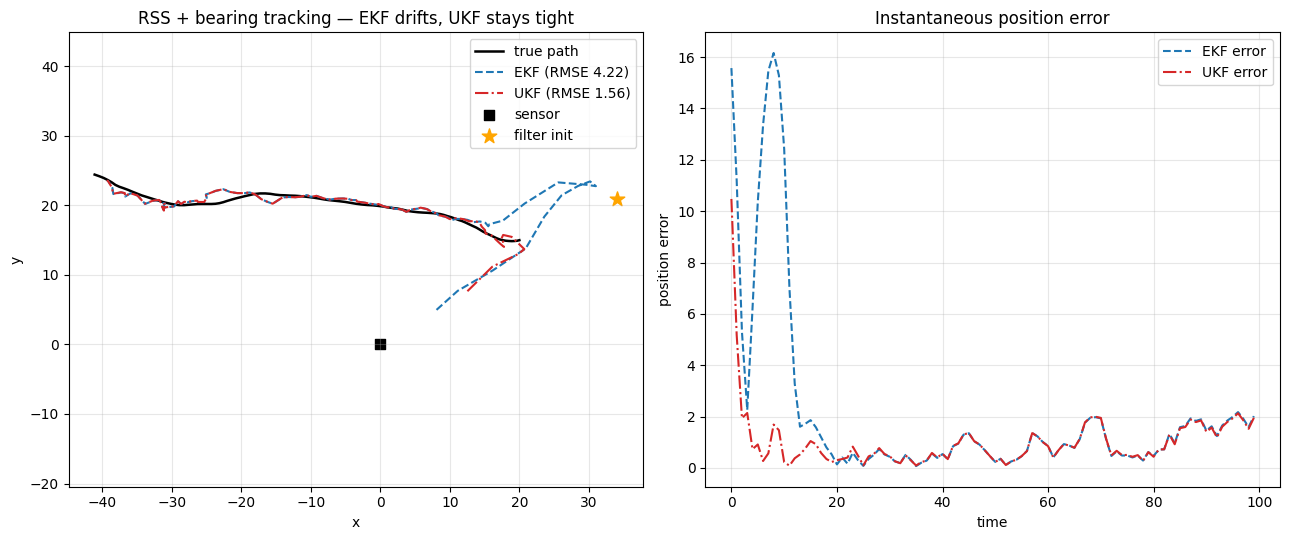

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(xy_true_rss[:, 0], xy_true_rss[:, 1], 'k-', lw=1.8, label='true path')
ax.plot(xy_ekf_rss[:, 0], xy_ekf_rss[:, 1], 'C0--',
        label=f'EKF (RMSE {rmse_ekf_bad:.2f})')
ax.plot(xy_ukf_rss[:, 0], xy_ukf_rss[:, 1], 'C3-.',
        label=f'UKF (RMSE {rmse_ukf_bad:.2f})')
ax.scatter([0], [0], marker='s', s=60, color='k', label='sensor')
ax.scatter([a1_rss[0]], [a1_rss[2]], marker='*', s=120, color='orange',
           label='filter init')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('RSS + bearing tracking — EKF drifts, UKF stays tight')
ax.legend(loc='best')
ax.set_aspect('equal', adjustable='datalim')

err_ekf_rss = np.sqrt(np.sum((xy_ekf_rss - xy_true_rss) ** 2, axis=1))
err_ukf_rss = np.sqrt(np.sum((xy_ukf_rss - xy_true_rss) ** 2, axis=1))

ax2 = axes[1]
ax2.plot(t_rss, err_ekf_rss, 'C0--', label='EKF error')
ax2.plot(t_rss, err_ukf_rss, 'C3-.', label='UKF error')
ax2.set_xlabel('time')
ax2.set_ylabel('position error')
ax2.set_title('Instantaneous position error')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()


## Quantitative summary

The table below collects RMSE and runtime for the two filters on each of
the scenarios.


In [10]:
summary = pd.DataFrame({
    'scenario': [
        'pendulum (sin(theta))',
        'target tracking (range+bearing)',
        'target tracking (RSS+bearing, hard)',
    ],
    'metric': ['RMSE(theta)', 'RMSE(position)', 'RMSE(position)'],
    'EKF': [rmse_theta_ekf, rmse_ekf_pos, rmse_ekf_bad],
    'UKF': [rmse_theta_ukf, rmse_ukf_pos, rmse_ukf_bad],
    'EKF time (ms)': [time_ekf_pend * 1e3, time_ekf_targ * 1e3, np.nan],
    'UKF time (ms)': [time_ukf_pend * 1e3, time_ukf_targ * 1e3, np.nan],
})
summary['UKF / EKF ratio'] = (summary['UKF'] / summary['EKF']).round(3)
summary['UKF beats EKF'] = summary['UKF'] < summary['EKF']
summary.round(4)


,scenario,metric,EKF,UKF,EKF time (ms),UKF time (ms),UKF / EKF ratio,UKF beats EKF
0,pendulum (sin(theta)),RMSE(theta),0.3793,0.2022,32.3989,74.0264,0.533,True
1,target tracking (range+bearing),RMSE(position),3.6081,3.6104,17.4532,49.8016,1.001,False
2,"target tracking (RSS+bearing, hard)",RMSE(position),4.2161,1.5634,NaN,NaN,0.371,True


## Conclusions

| Observation | EKF | UKF |
|---|---|---|
| Needs analytic Jacobians | yes | no |
| Cost per step | 1 $f$ eval, 1 $h$ eval | $2n{+}1$ $f$ and $h$ evals |
| Mild nonlinearities (pendulum) | ~on par | ~on par |
| Strong nonlinearities (range/bearing) | worse | better |
| Catastrophic divergence with bad init | common | rarer |

**Rules of thumb.**

* Use EKF when (i) Jacobians are cheap to derive **and** (ii) the
  nonlinearity is mild around the operating point.
* Use UKF when (i) the Jacobian is awkward (e.g. involves $\mathrm{atan2}$,
  neural networks, black-box simulators), **or** (ii) the filter may
  be initialised far from the truth, **or** (iii) second-moment
  accuracy matters (e.g. for decision-making under uncertainty).

Neither filter produces exact posteriors for nonlinear systems; both
are *approximate* inference. When approximations fail catastrophically
(strong non-Gaussianity, multi-modality), particle filters or
ensemble filters are the next step.
